In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
.inner_cell{font-size:20pt;}
div.text_cell_render pre code {font-size:20pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

<font size="6" color="red">ch12. 데이터 시각화</font>
- 시각화 라이브러리 : matplotlib, seaborn, folium(지도시각화)

- matplolib : 파이썬에서 가장 기본적으로 사용하는 시각화 라이브러리. 판다스 내부에 포함
- seaborn : matplotlib 기반으로 다양한 색, 테마, 챠트 기능과 groupby 기능을 추가한 라이브러리

# 1절. matplotlib
- api 참조 url : https://matplotlib.org/stable/api/index.html

## 1.1 패키지 import 및 기본 설정

In [2]:
import matplotlib
matplotlib.__version__

'3.7.0'

%matplotlib inline : 주피터노트북이 실행되는 브라우저에서 시각화 바로 하도록

In [3]:
import matplotlib.pyplot as plt
# from matplotlib import pyplot as plt
# 시각화한 그래프를 저장할 해상도 높이기
%config InlineBackend.figure_format = 'retina'
# 한글 설정(Win/MacOS)
plt.rc('font', family='Malgun Gothic') # 윈도우즈
# plt.rc('font', family='AppleGothic') # MacOS
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지

# warning(경고) 안보이게
import warnings
# warnings.filterwarnings(action='ignore') # 경고 메세지 안 보이게
# warnings.filterwarnings(action='default') # 기본 경고 메세지 다 보이게
import seaborn as sns

## 1.2 그래프 그리기
- matplolib으로 그래프를 그리기 위한 단계
    1) 데이터 준비
    2) 그래프 생성
    3) 그래프 함수로 그리기
    4) 그래프 커스터마이징
    5) 그래프 출력 및 저장

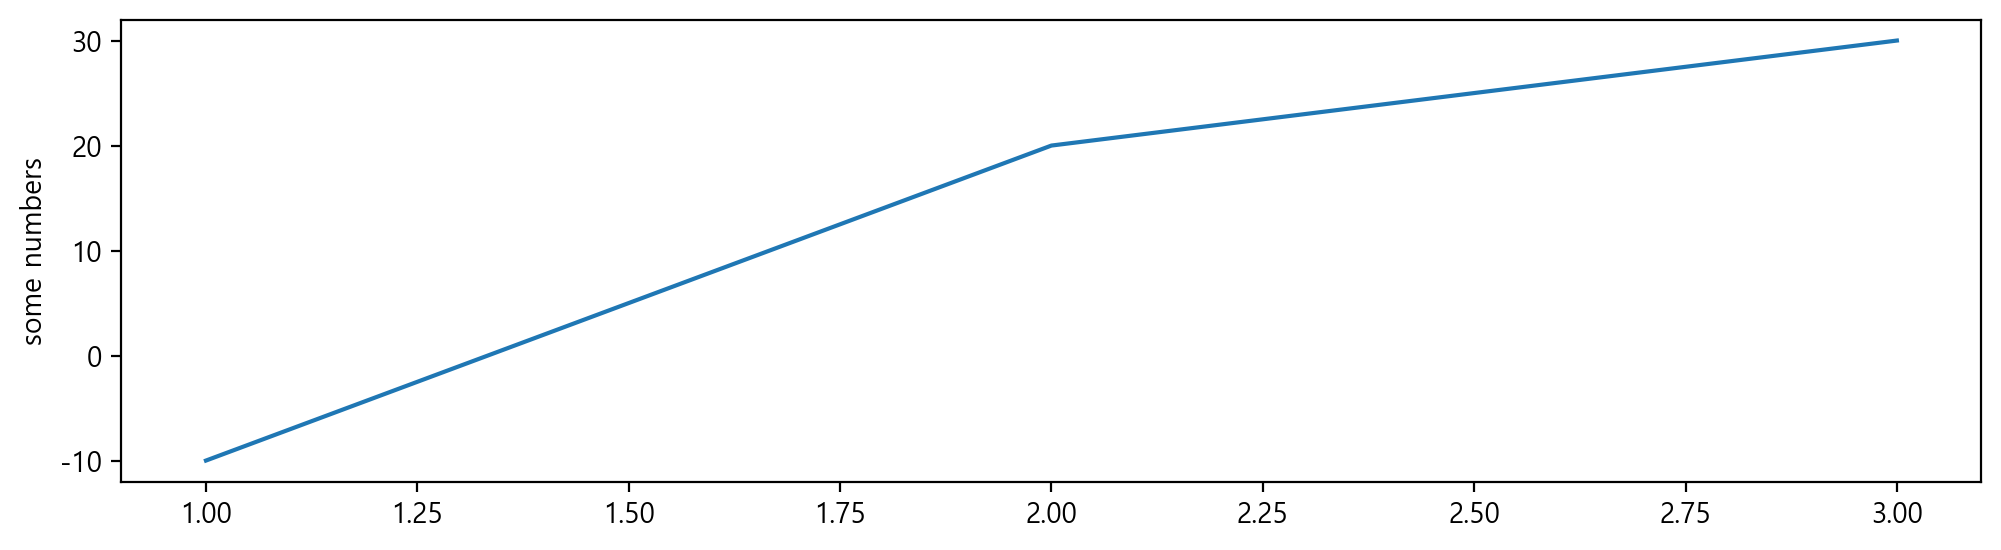

In [4]:
x = [1, 2, 3] # 1)데이터 준비
y = [-10, 20, 30]
plt.figure(figsize=(12, 3)) # 2)원하는 사이즈의 그래프 객체 생성
plt.plot(x, y) # 3) 그래프 함수로 그리기
plt.ylabel('some numbers') # 4) 커스터마이징
plt.savefig('data/ch12_plot.png', bbox_inches='tight', dpi=300) # 5) 그래프 저장
plt.show() # 그래프 출력

## 1.3 그래프 영역 나누기
### 1) subplot()함수로 서브플롯 추가

In [5]:
import numpy as np
x = np.linspace(0, 9.9, 100)
x.shape

(100,)

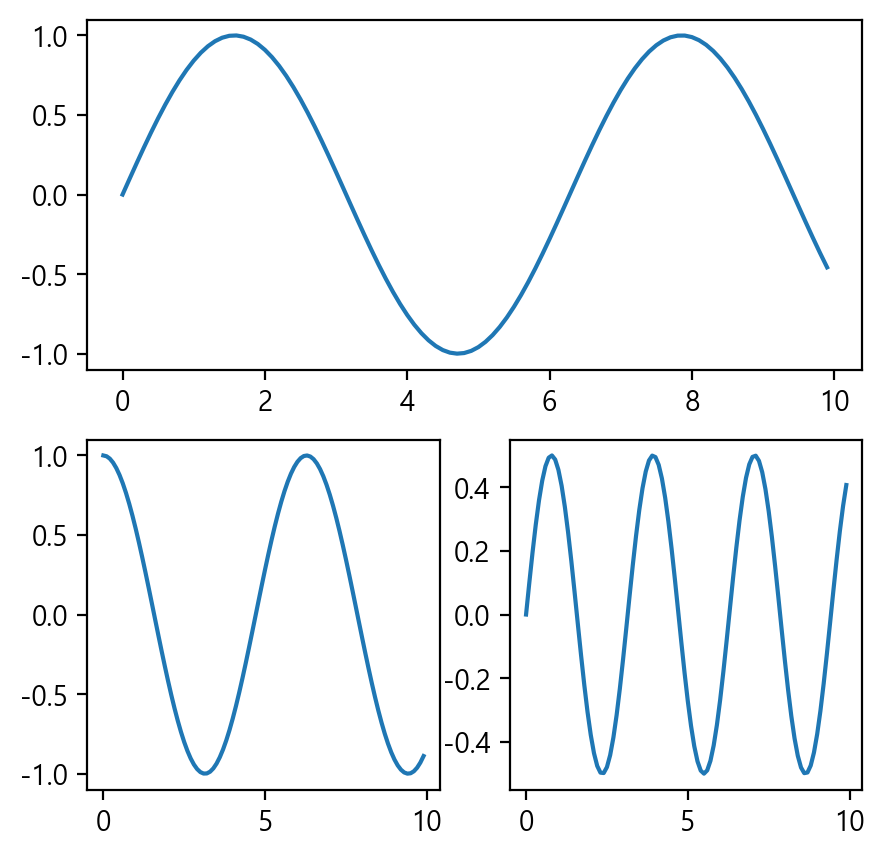

In [6]:
# plt.figure(figsize=(5,5)) # 그래프 사이즈가 이번 셀만
plt.rcParams['figure.figsize'] = (5,5) # 그래프 사이즈 셋팅(다음셀도 적용)
plt.subplot(2, 1, 1) # 2행1열의 subplot에서 1번째 subplot을 다음과 같이 그린다
plt.plot(x, np.sin(x))
plt.subplot(2, 2, 3) # 2행2열의 subplot에서 3번째 subplot을 다음과 같이 그린다
plt.plot(x, np.cos(x))
#plt.subplot(2, 2, 4)
plt.subplot(224)
plt.plot(x, np.sin(x)*np.cos(x))
plt.show()

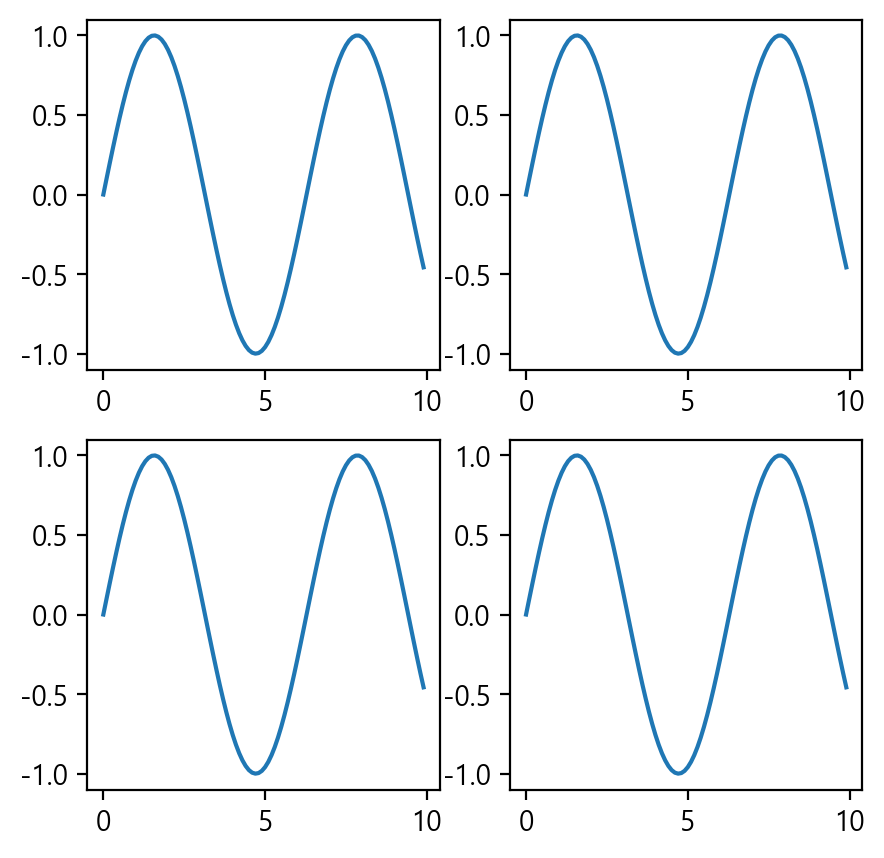

In [7]:
plt.subplot(221); plt.plot(x, np.sin(x)) # 2행2열 1번째 plot
plt.subplot(222); plt.plot(x, np.sin(x)) # 2행2열 2번째
plt.subplot(223); plt.plot(x, np.sin(x))
plt.subplot(2,2,4); plt.plot(x, np.sin(x))
plt.show()

### 2) subplots()함수로 서브플롯 생성
- plot함수에서 색상이나 스타일을 조정 : https://wikidocs.net/92085 

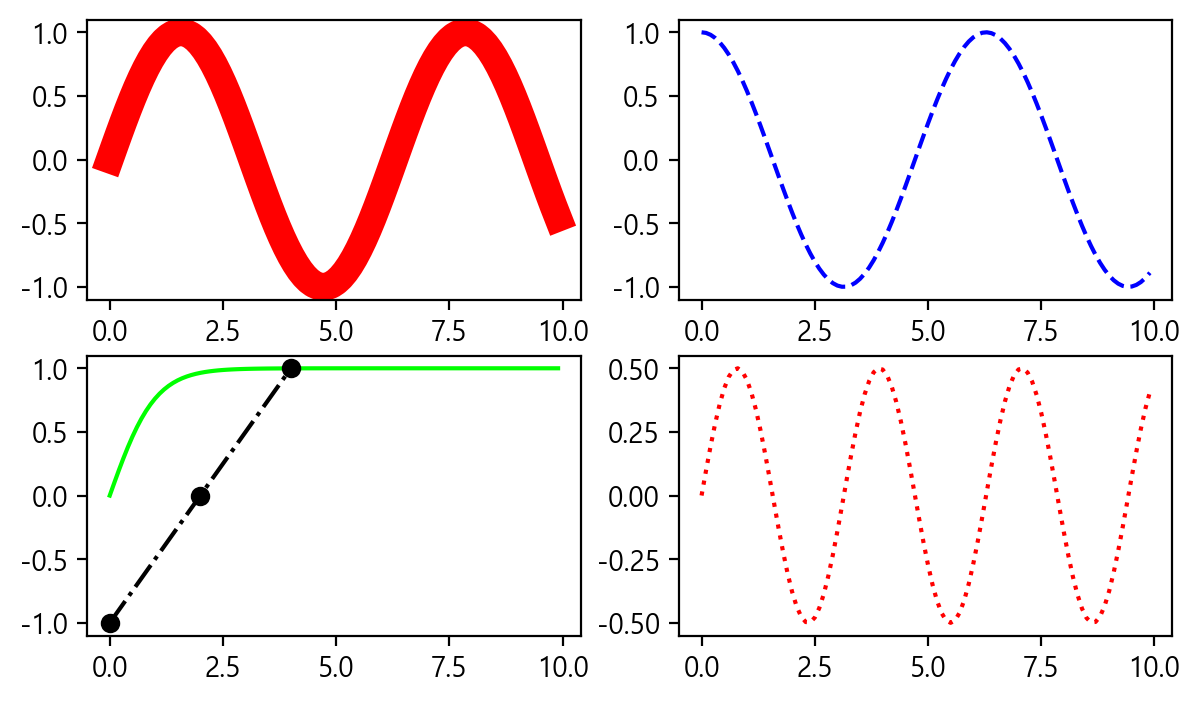

In [8]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(7,4))
axes[0,0].plot(x, np.sin(x), c='r', lw=10) # color='r', linewidth=10
axes[0,1].plot(x, np.cos(x), 'b--') # color='b', linestyle='--'(대시라인), :(점선)
axes[1,0].plot(x, np.tanh(x), '#00FF00') # c='#00FF00'
axes[1,0].plot([0,2,4],[-1,0,1], 'ko-.') # c='k', marker='o', linestyle='-.'
axes[1,1].plot(x, np.sin(x)*np.cos(x), 'r:')
plt.show()

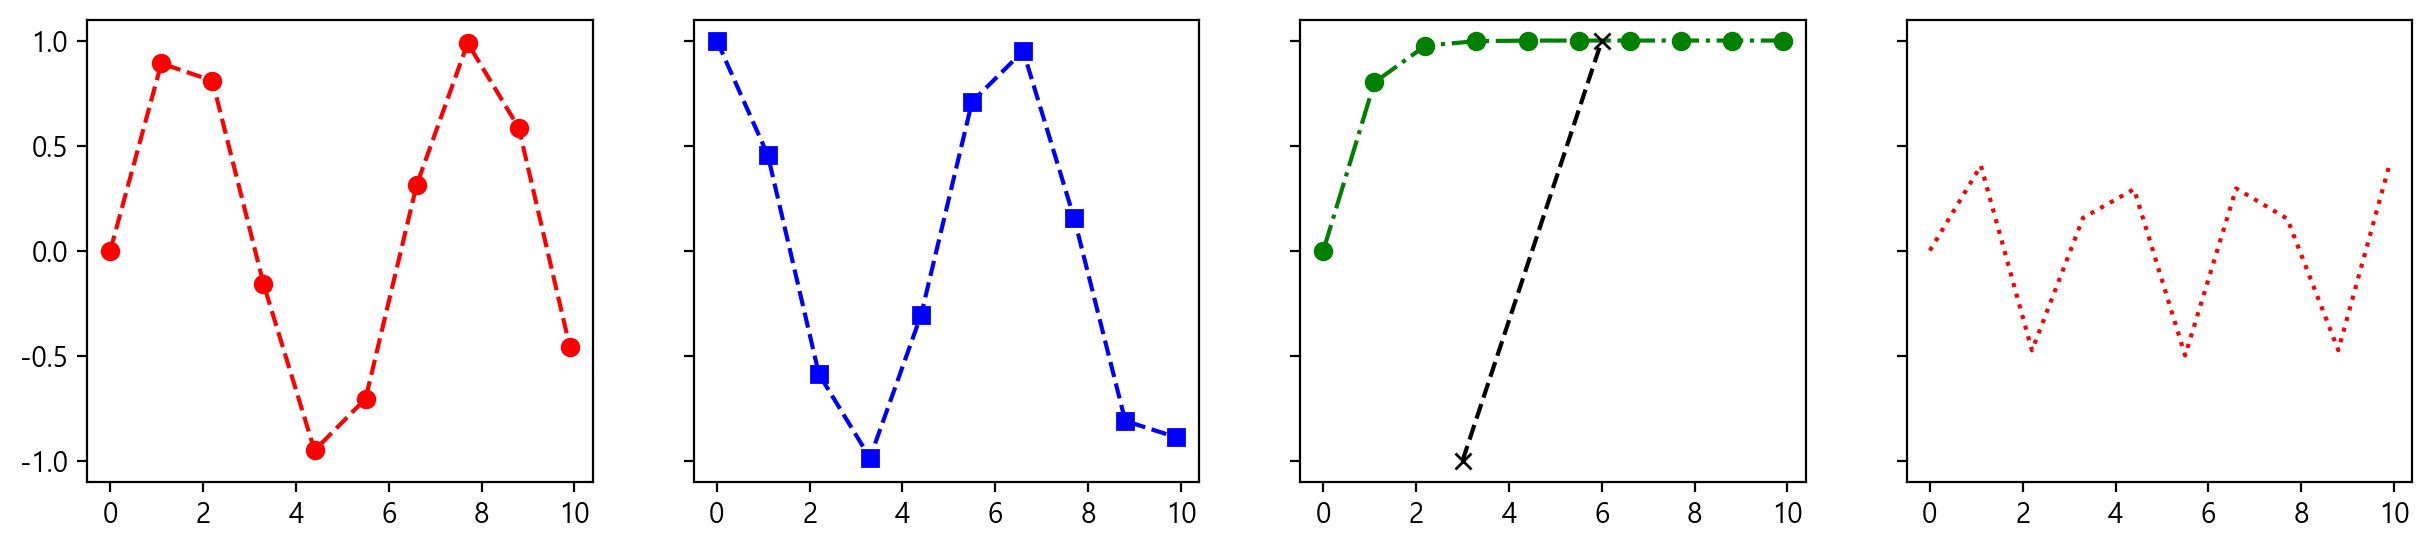

In [9]:
# 1행4열 서브플롯 (for문)
x = np.linspace(0, 9.9, 10)
func_list = [np.sin, np.cos, np.tanh, lambda x:np.sin(x)*np.cos(x)]
fmt_list  = ['ro--', 'bs--', 'go-.', 'r:']
fig, axes = plt.subplots(1, 4, figsize=(15,3), sharey=True) # y축공유
for i, ax in enumerate(axes):
    ax.plot(x, func_list[i](x), fmt_list[i])
axes[2].plot([3,6],[-1, 1], 'kx--')
plt.show()

## 1.4 다양한 그래프 그리기
### 1) pyplot 함수들 (교안 16.)
    https://matplotlib.org/api/_as_gen/matplotlib.pyplot.html
### 2) matplotlib.pyplot.plot() : 선그래프

In [10]:
# c, color(칼라) : https://wikidocs.net/92085
# marker = o, ^, x, s
# linestyle = -(실선), --(대시라인), :(점선), -.

### 3) pandas.DataFrame.plot()
- plt.plot(x, y, fmt)
- df.plot(x=None, y=None, kind='line', figsize=None, title=None, grid=None, xlim, ylim...)
    * kind : line(기본값), scatter(점도표), bar(막대), barh(가로막대), box, density=kde밀도추청, hist(빈도)...
    * figsize : tuple(인치단위)
    * xlim, ylim(축의 범위) : list/tuple

In [11]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.sample(2)

,sepal_length,sepal_width,petal_length,petal_width,species
61,5.9,3.0,4.2,1.5,versicolor
84,5.4,3.0,4.5,1.5,versicolor


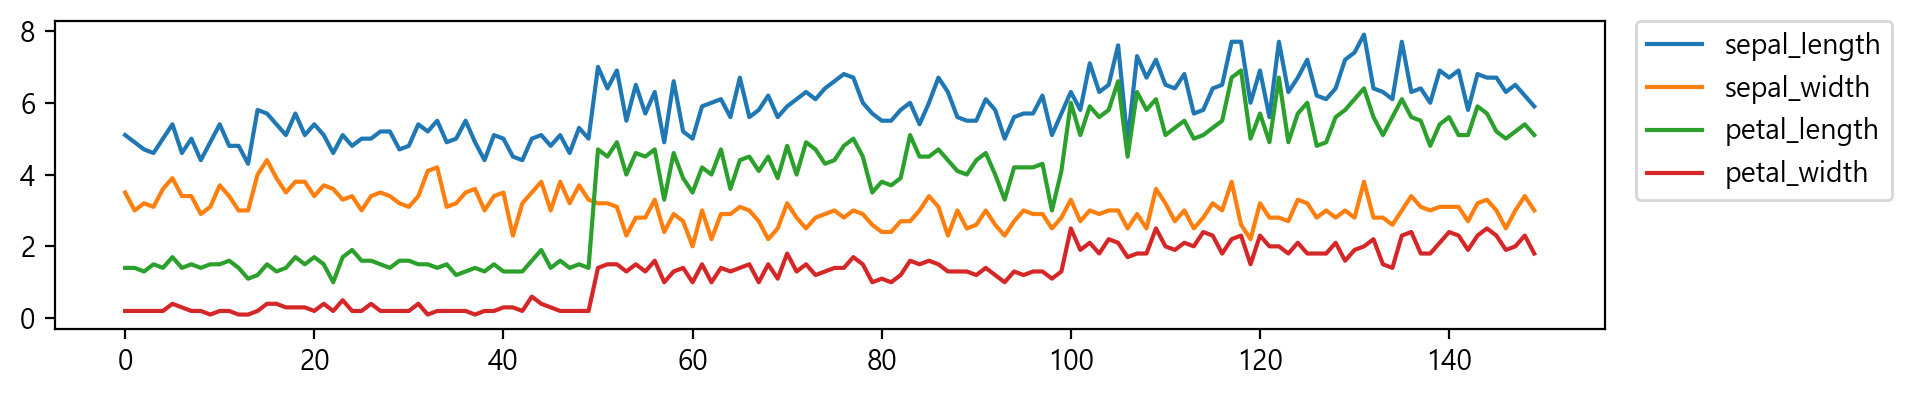

In [12]:
# 이렇게는 안하고 아래처럼
plt.rcParams['figure.figsize'] = (10,2)
plt.plot(iris.index, iris.iloc[:, :-1])
#plt.legend(iris.columns[:-1])
plt.legend(iris.columns[:-1], bbox_to_anchor=(1.02, 1), loc=2, borderaxespad=0.)
plt.show()

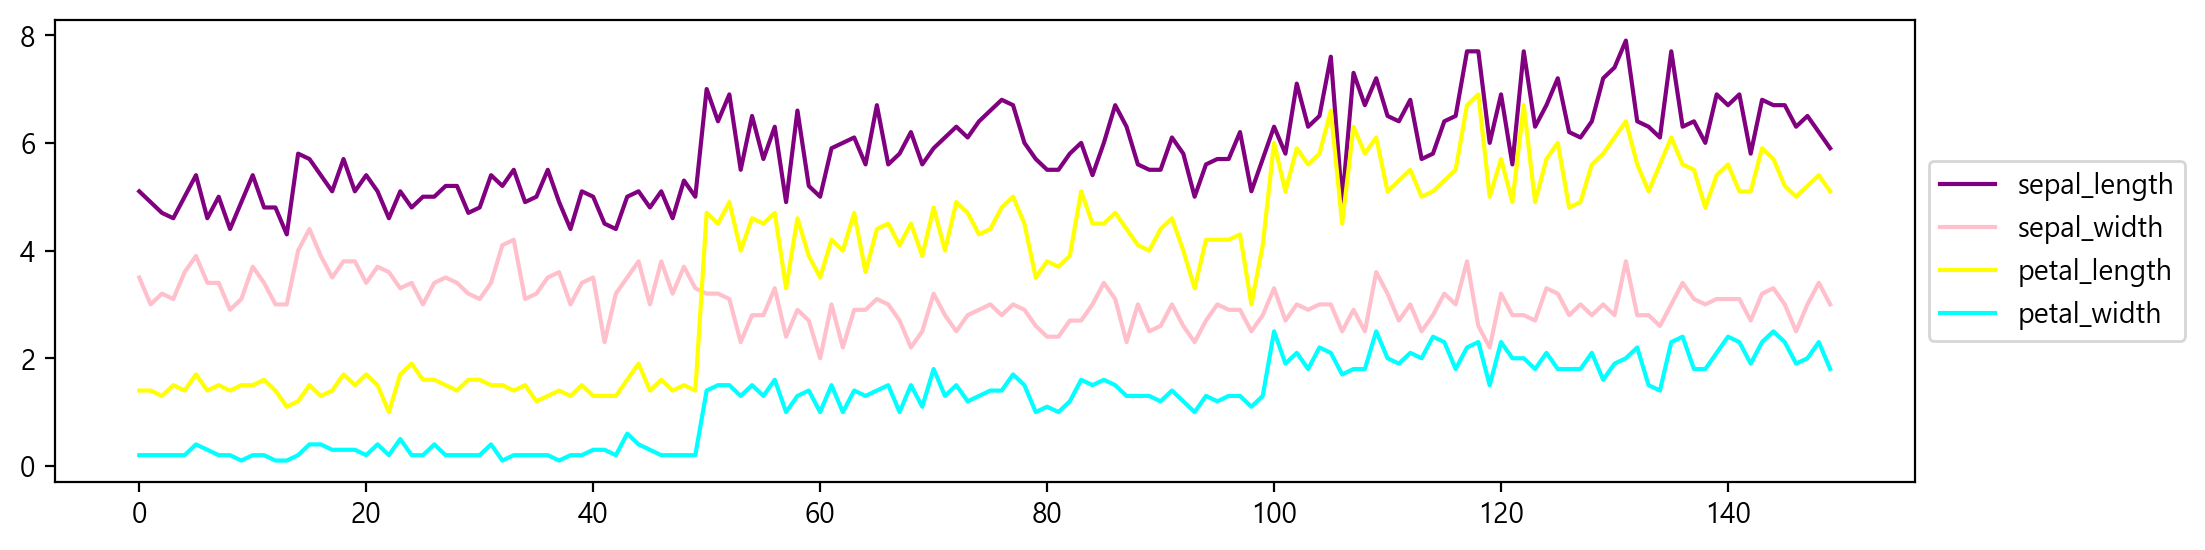

In [13]:
g = iris.plot(kind='line', # 그래프 종류
         figsize=(12,3), # 크기
         color=['purple','pink','yellow', 'cyan'], # 그래프 색상
         )
g.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

- 교안(21p)
    * https://ko.wikipedia.org/wiki/상자_수염_그림
    * https://matplotlib.org/stable/tutorials/colors/colormaps.html (colormap)

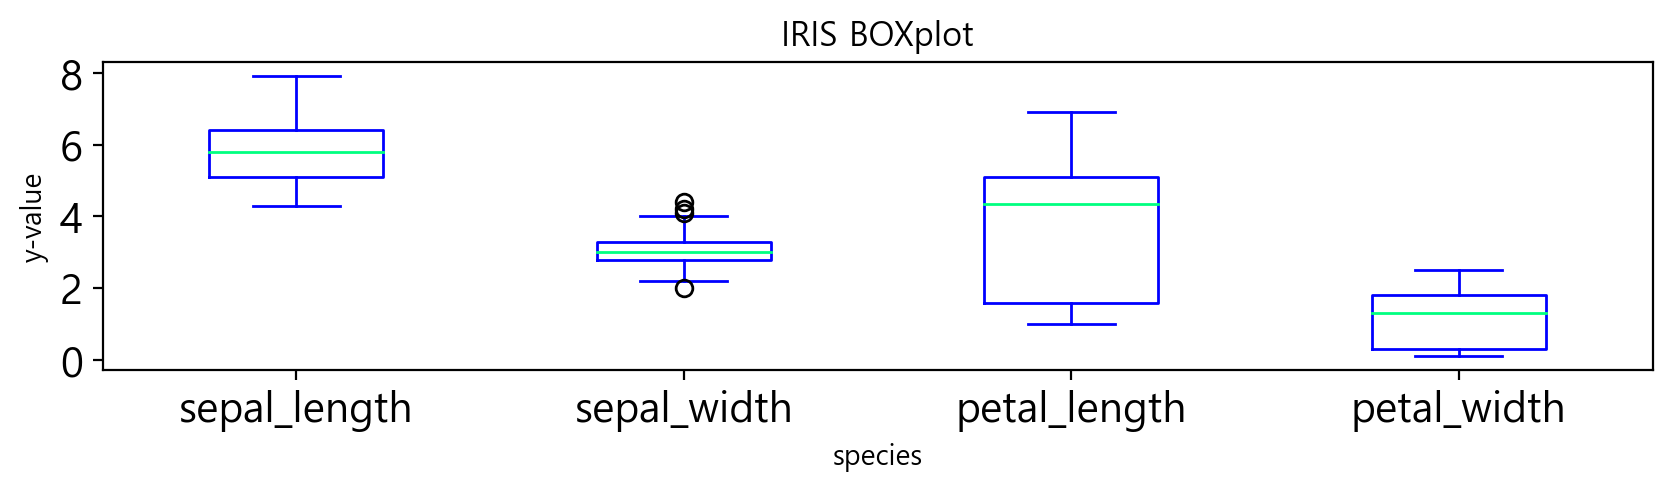

In [14]:
iris.plot(kind='box',
         colormap='winter',
         title='IRIS BOXplot',
         ylabel='y-value',
         xlabel='species',
         fontsize=15)
plt.show()

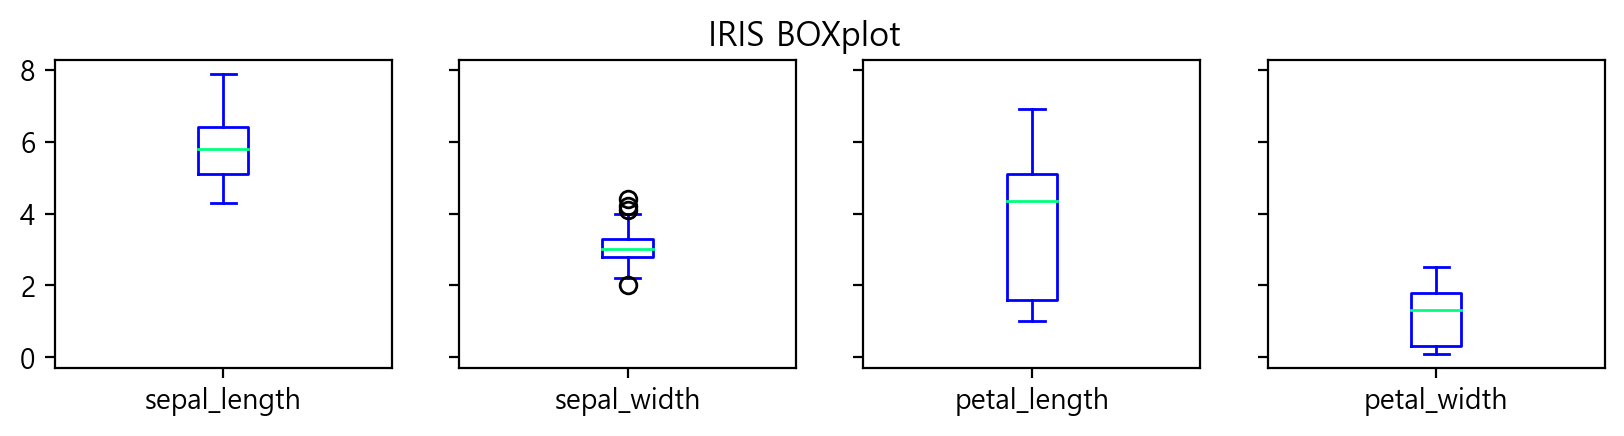

In [15]:
iris.plot(kind='box',
         colormap='winter',
         title='IRIS BOXplot',
         subplots=True,
         sharey=True)
plt.show()

In [16]:
iris.corr(numeric_only=True)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


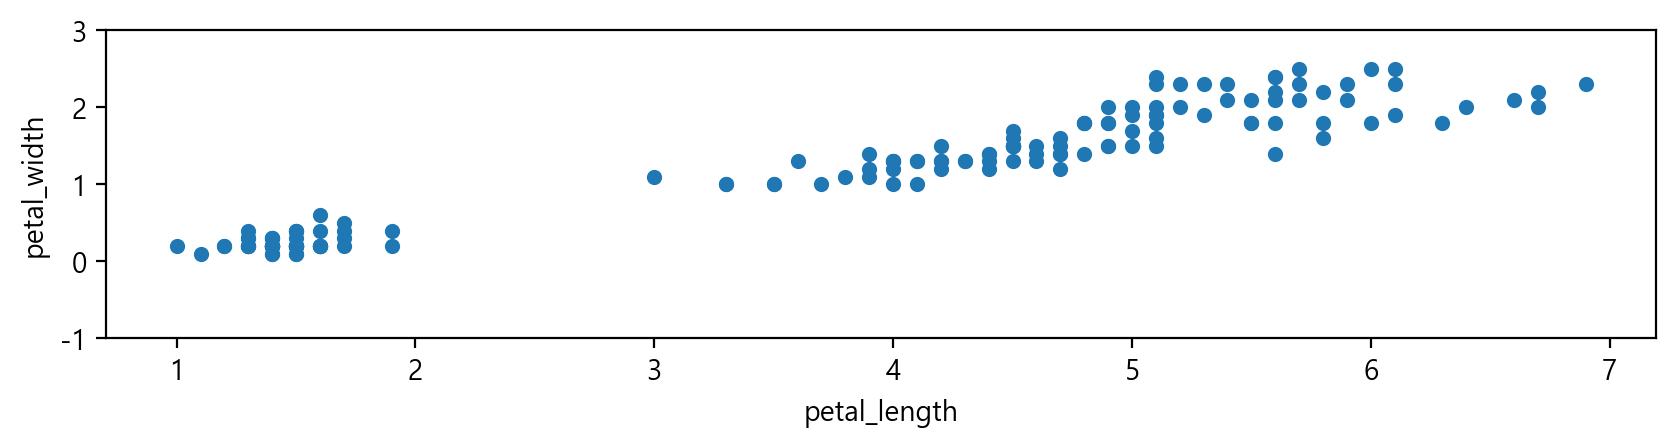

In [17]:
iris.plot(kind='scatter', x='petal_length', y='petal_width', ylim=[-1, 3]) # y축 범위 조정
plt.show()

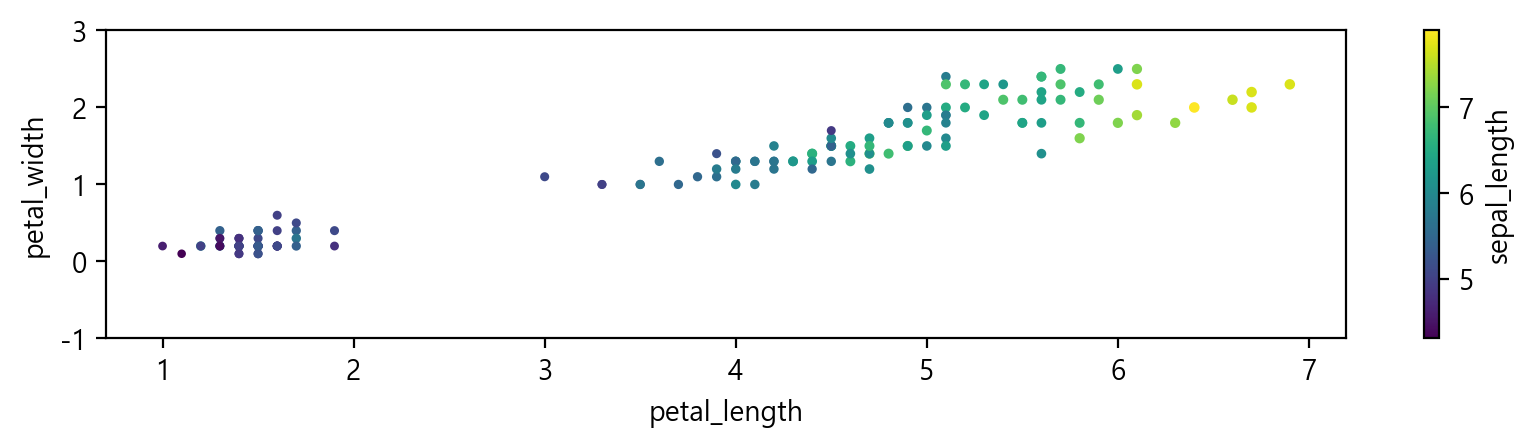

In [18]:
iris.plot(kind='scatter', x='petal_length', y='petal_width', 
          s='sepal_length', # 점의 size
          c='sepal_length', # 점의 color
          ylim=[-1, 3]) # y축 범위 조정
plt.show()

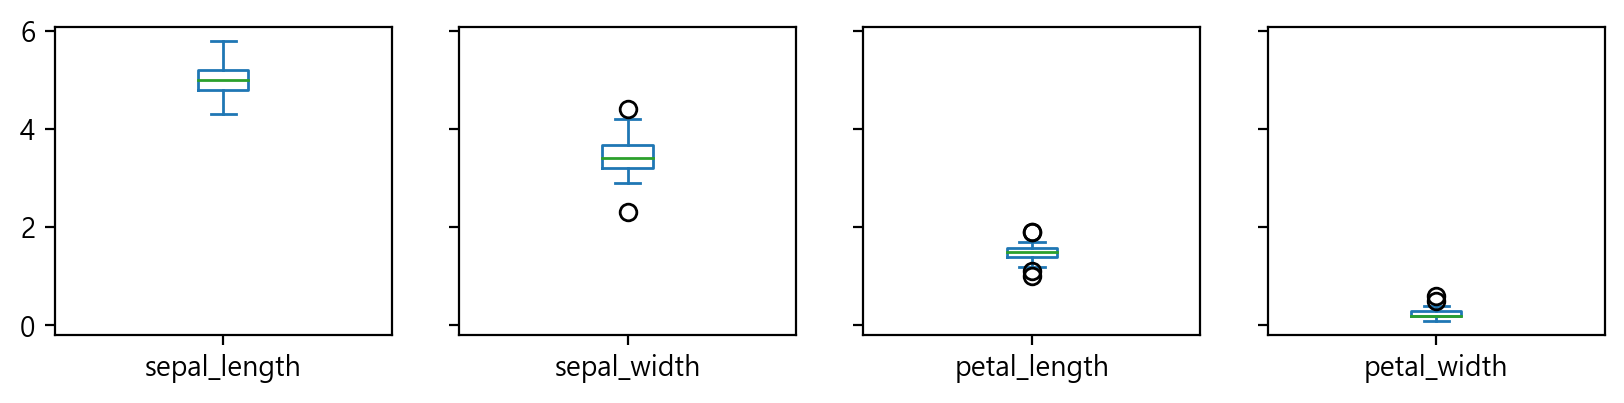

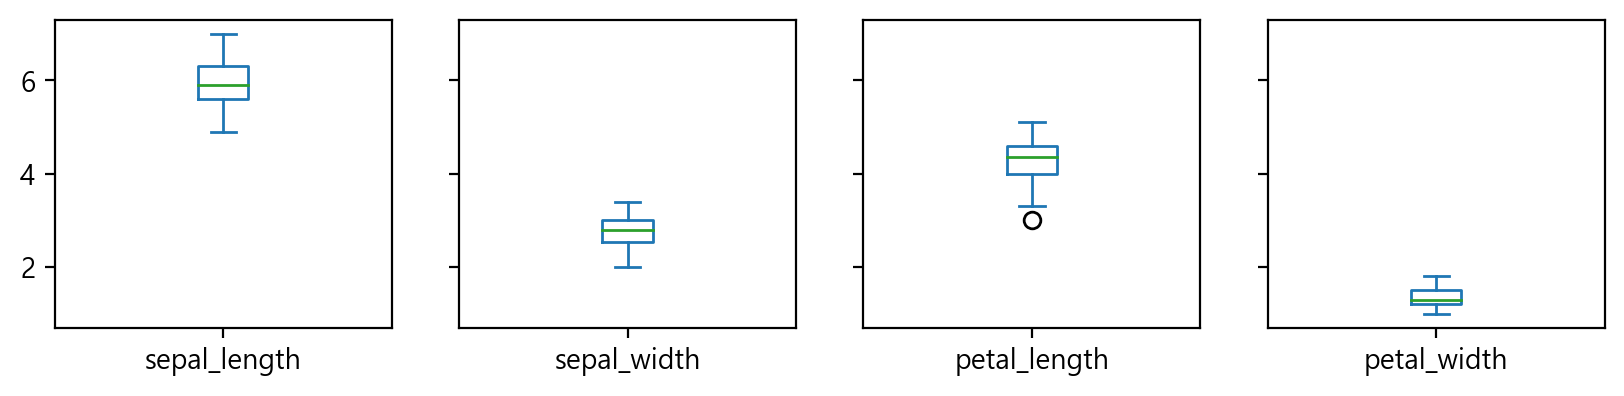

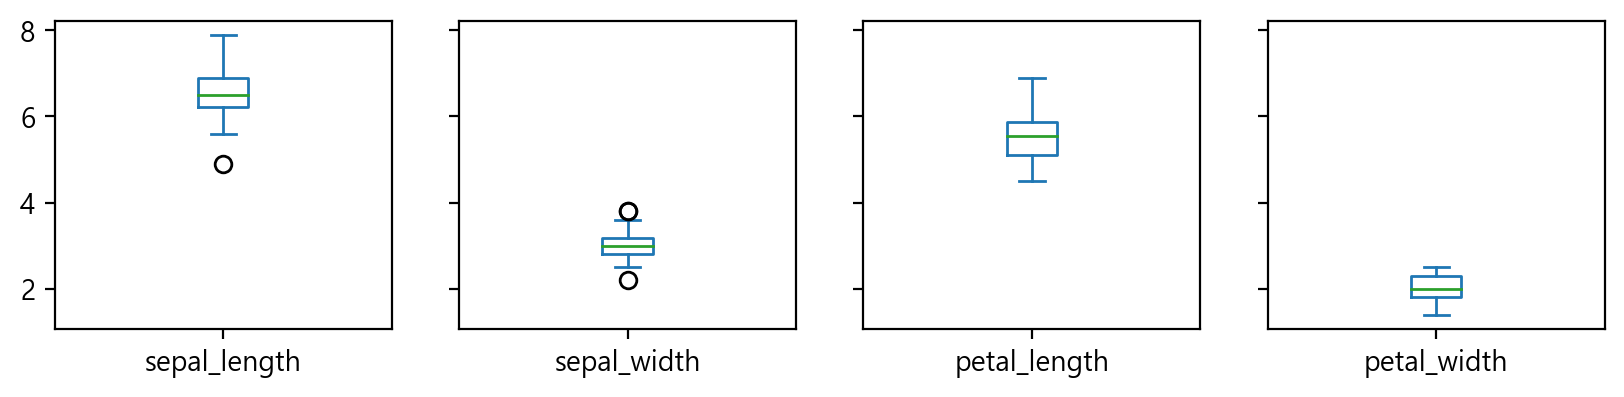

In [19]:
# 종별 boxplot
iris.groupby('species').plot(kind='box',
                            subplots=True,
                            sharey=True,
                            #layout=(3,4)
                            )
plt.show()

### 4) plt.scatter() : 산점도
- x, y축이 수치형

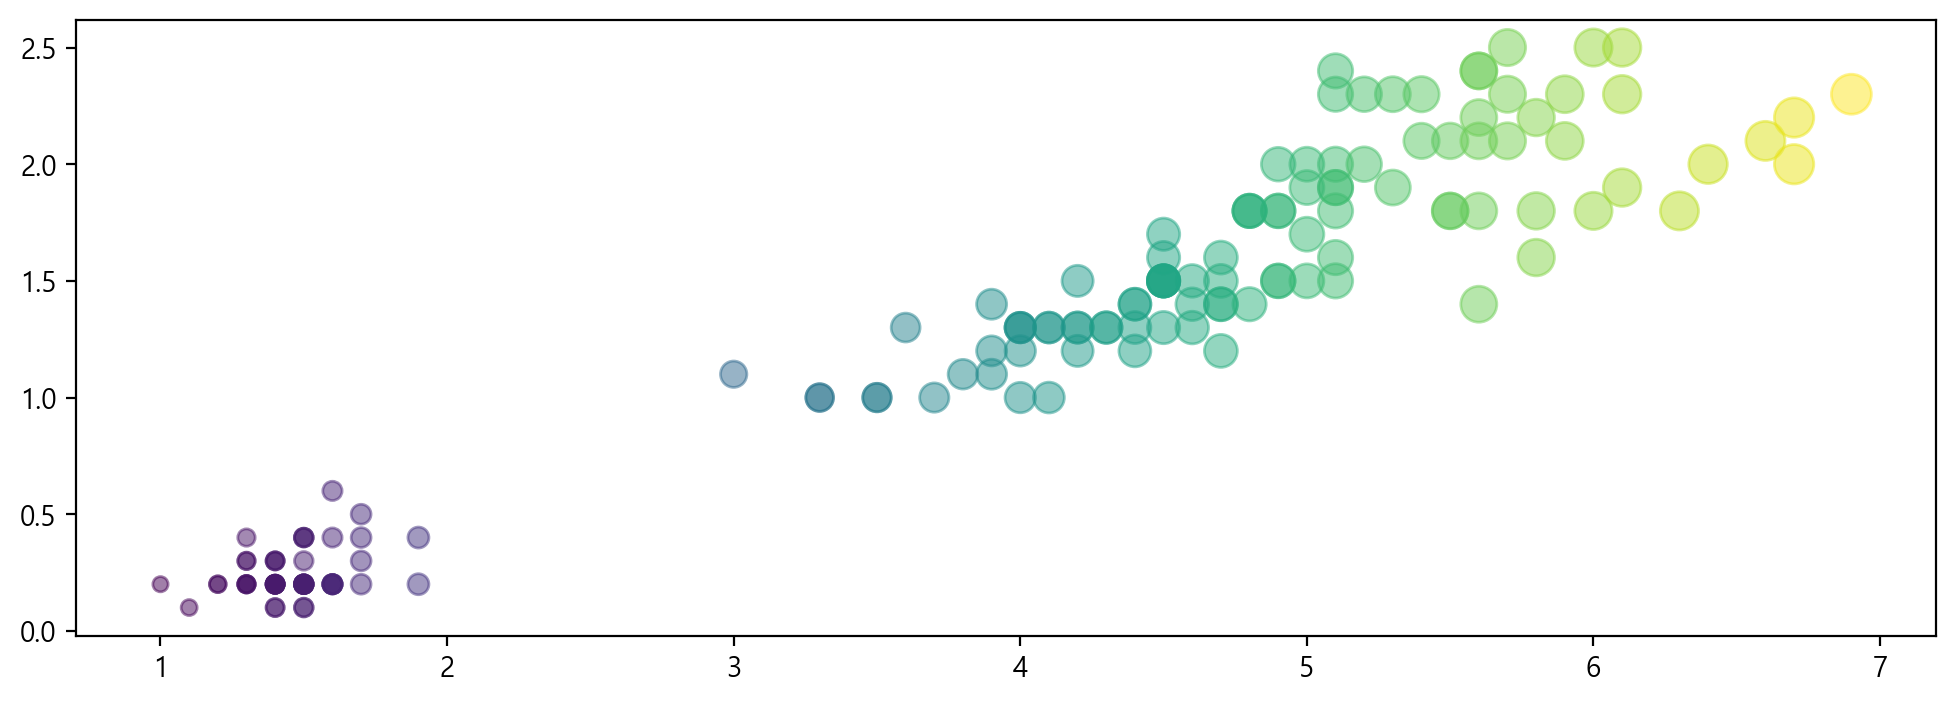

In [20]:
# plt.rcParams['figure.figsize'] = (10,2)
plt.figure(figsize=(12,4))
plt.scatter(iris.petal_length, iris.petal_width,
           s=iris.petal_length*30, # 점크기
           c=iris.petal_length*20,
           alpha=.5) # 투명도(투명0, 불투명1)
plt.show()

## 1.5 그 외 그래프 그리기
### 1) boxplot(분포를 몰라), violinplot(분포 보여줌)

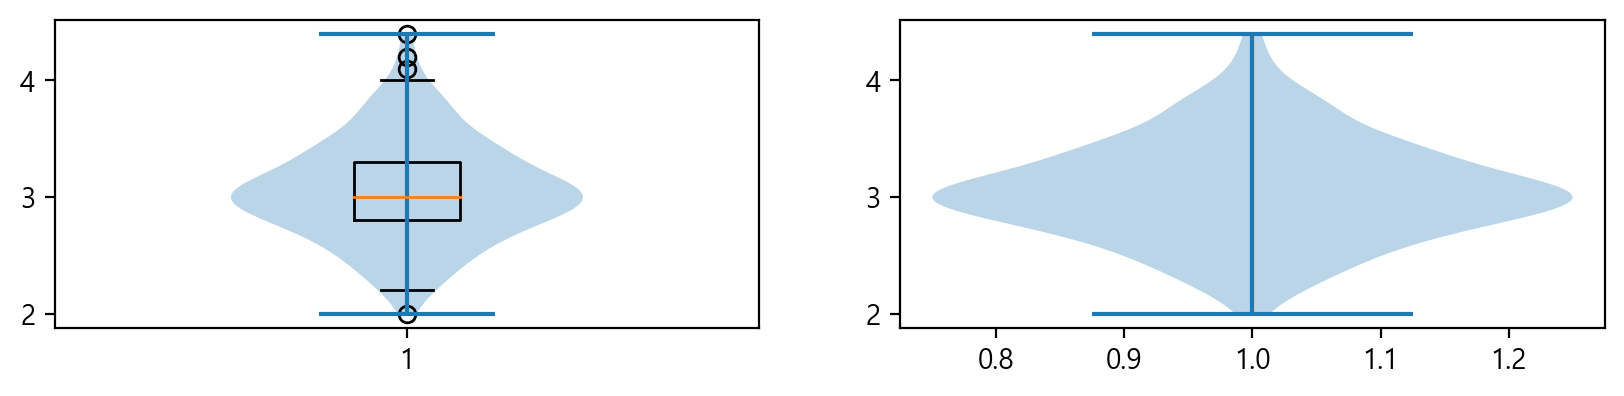

In [21]:
fig, axes = plt.subplots(ncols=2)
axes[0].boxplot(iris.sepal_width)
axes[0].violinplot(iris.sepal_width)
#sns.violinplot(y=iris.sepal_width, ax=axes[1])
axes[1].violinplot(iris.sepal_width)
plt.show()

### 2) bar(), barh()

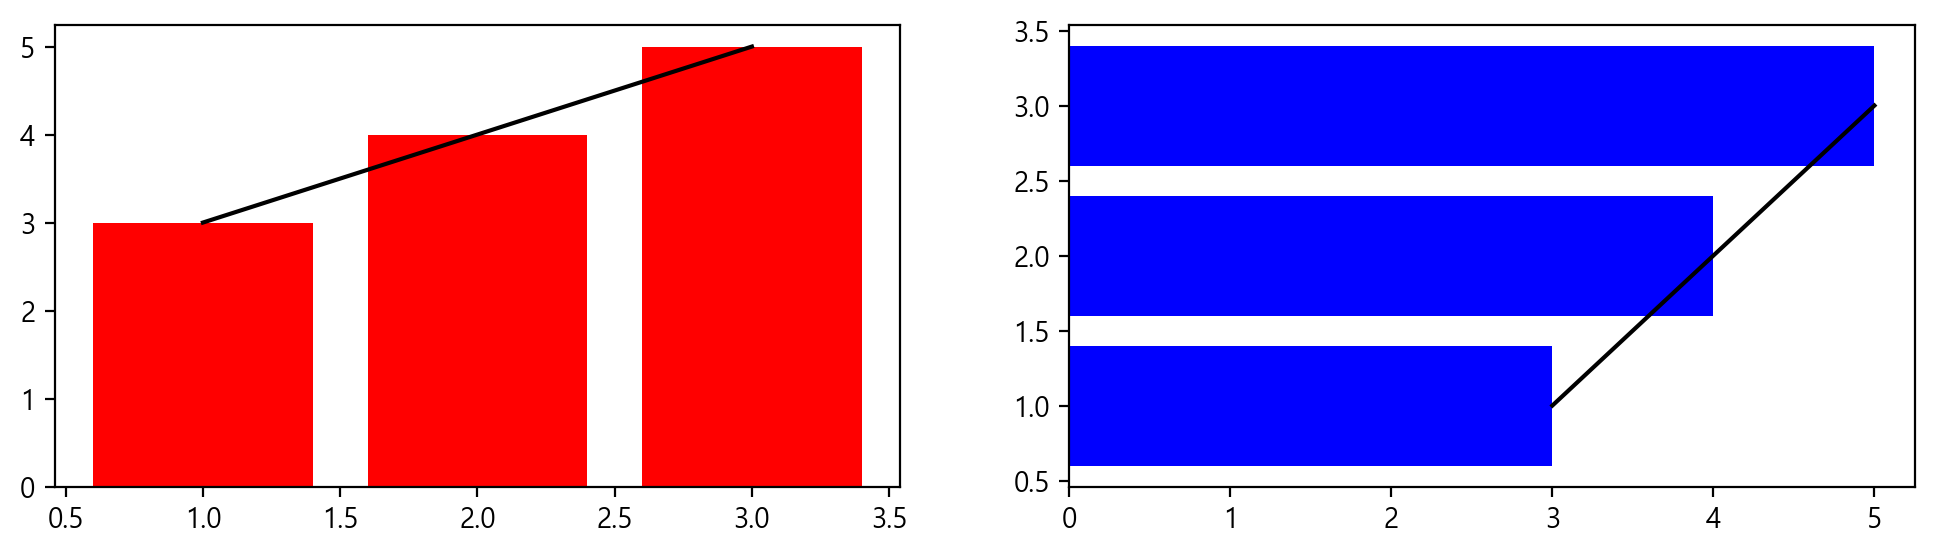

In [22]:
x = [1, 2, 3]
y = [3, 4, 5]
fig, axes = plt.subplots(ncols=2, figsize=(12, 3))
axes[0].bar(x, y, color='r')
axes[0].plot(x, y, c='k')
axes[1].barh(x, y, color='b') # 가로막대 그래프는 x와 y가 바뀜
axes[1].plot(y, x, 'k')

### 3) hist(히스토그램. 도수분포표를 그래프화)

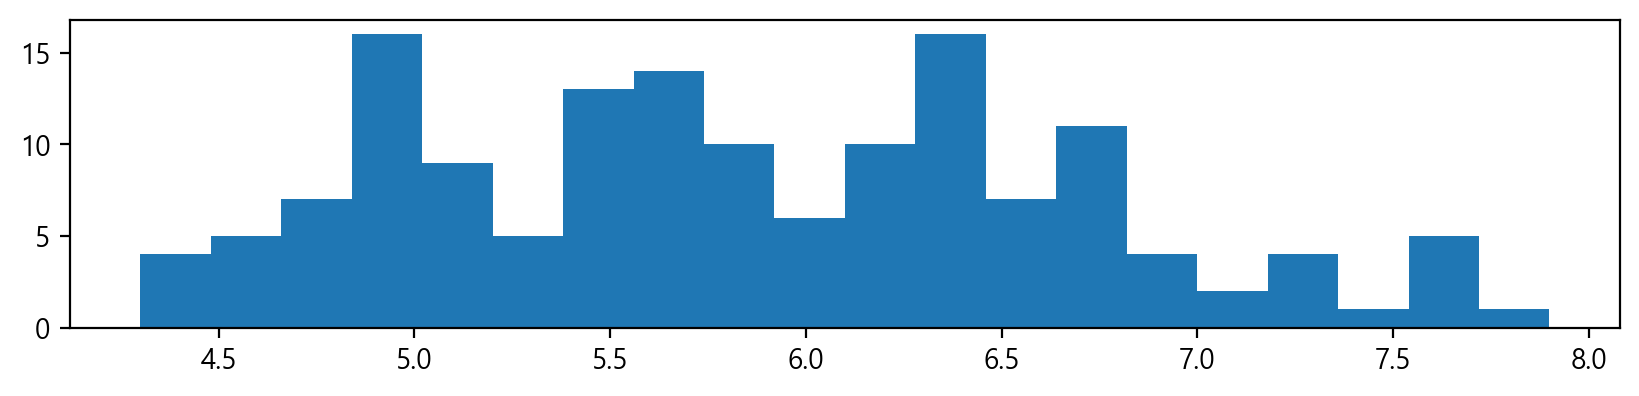

In [23]:
# plt.hist(iris.sepal_length, bins=20, orientation='horizontal') # 가로 histogram
# plt.hist(iris.sepal_length, bins=20, cumulative=True) # 누적 histogram
plt.hist(iris.sepal_length, bins=20)
plt.show()

### 4) axvline(), axhline(), fill(), fill_between()

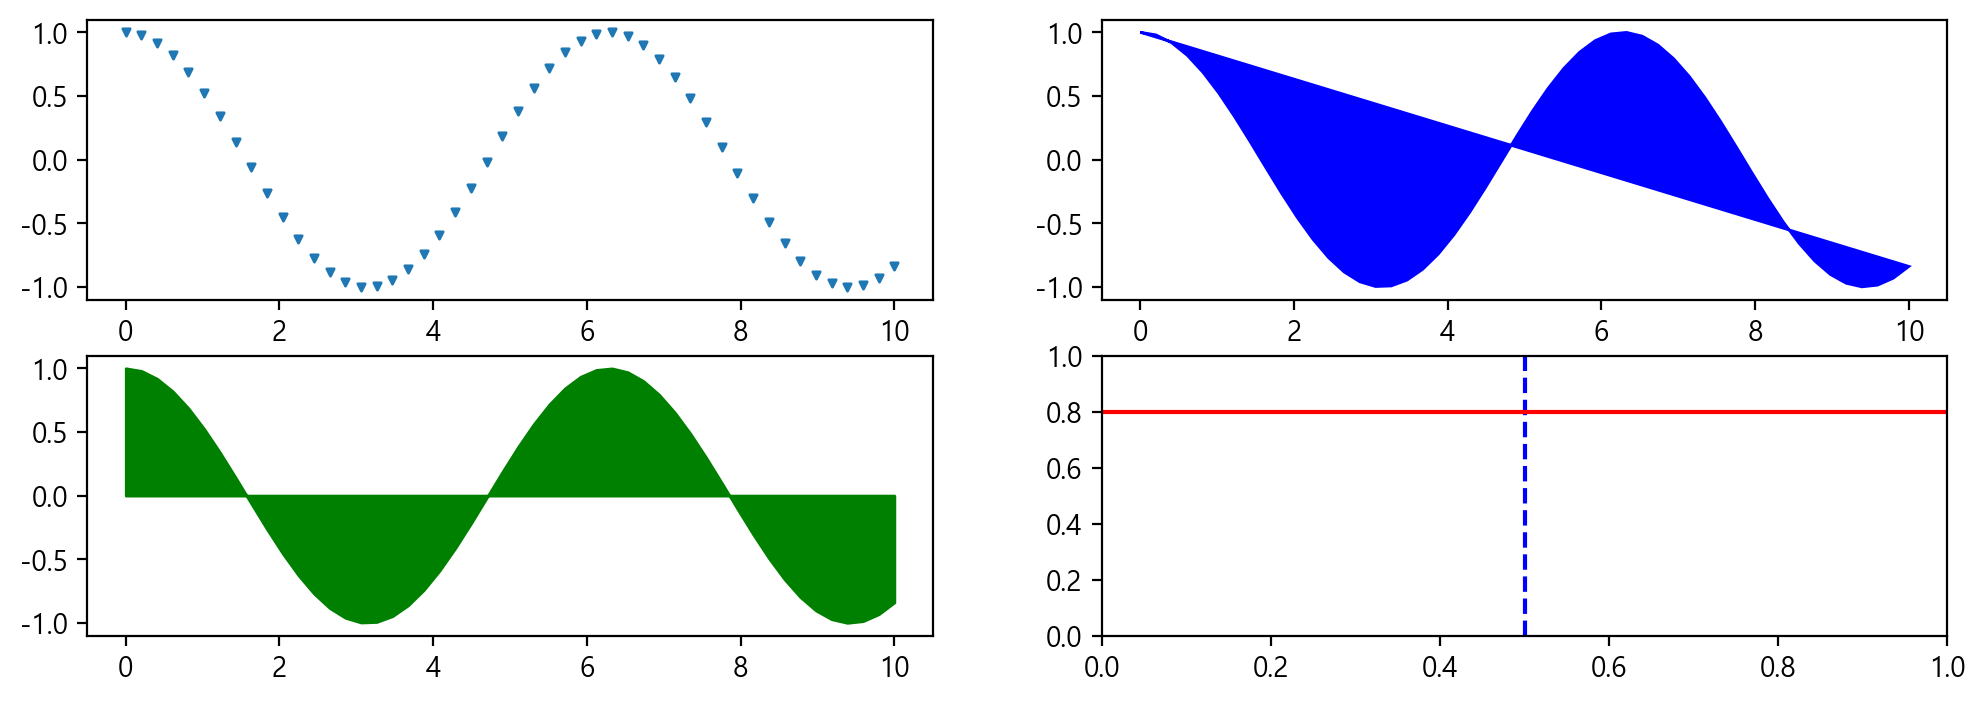

In [24]:
x = np.linspace(0, 10) # 50개 데이터 생성
y = np.cos(x)
fig, axes = plt.subplots(2, 2, figsize=(12,4))
axes[0,0].scatter(x, y, s=7, marker='v')
axes[0,1].fill(x, y, c='b')
axes[1,0].fill_between(x, y, color='g')
axes[1,1].axvline(0.5, c='b', linestyle='--')
axes[1,1].axhline(0.8, c='r')
plt.show()

### 5) pie

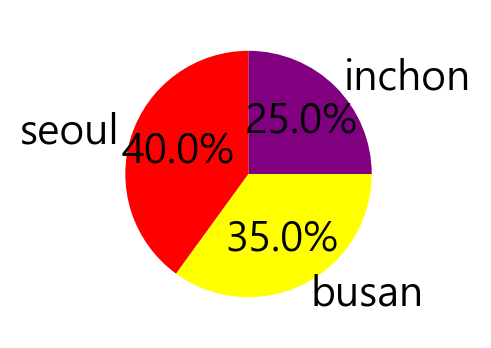

In [25]:
cnt = [40, 35, 25]
labels = ['seoul', 'busan', 'inchon']
colors = ['red', 'yellow', 'purple']
plt.pie(cnt, startangle=90,
       autopct="%.1f%%",
       textprops={'fontsize':15},
       labels=labels,
       colors=colors)
plt.show()

## 1.6 그래프 커스터마이징
### 1) linestyle, linewidth, color, marker...
### 2) text(), annotate()
- 교안 29p. https://matplotlib.org/stable/api/axes_api.html#text-and-annotations

In [26]:
# 한글 기본 폰트 설정 방법1
plt.style.use('default') #default
plt.rc('font', family='Malgun Gothic') # 윈도우즈
# plt.rc('font', family='AppleGothic') # MacOS
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지

In [27]:
# 한글 특정 폰트 설정 방법2
from matplotlib.font_manager import FontProperties
font_path = 'C:/Windows/Fonts/HMFMPYUN.TTF'
# 폰트 다운로드 : 네이버, 구글, 눈누, 산들 등에서 ttf 파일 
font_prop = FontProperties(fname=font_path, size=20)

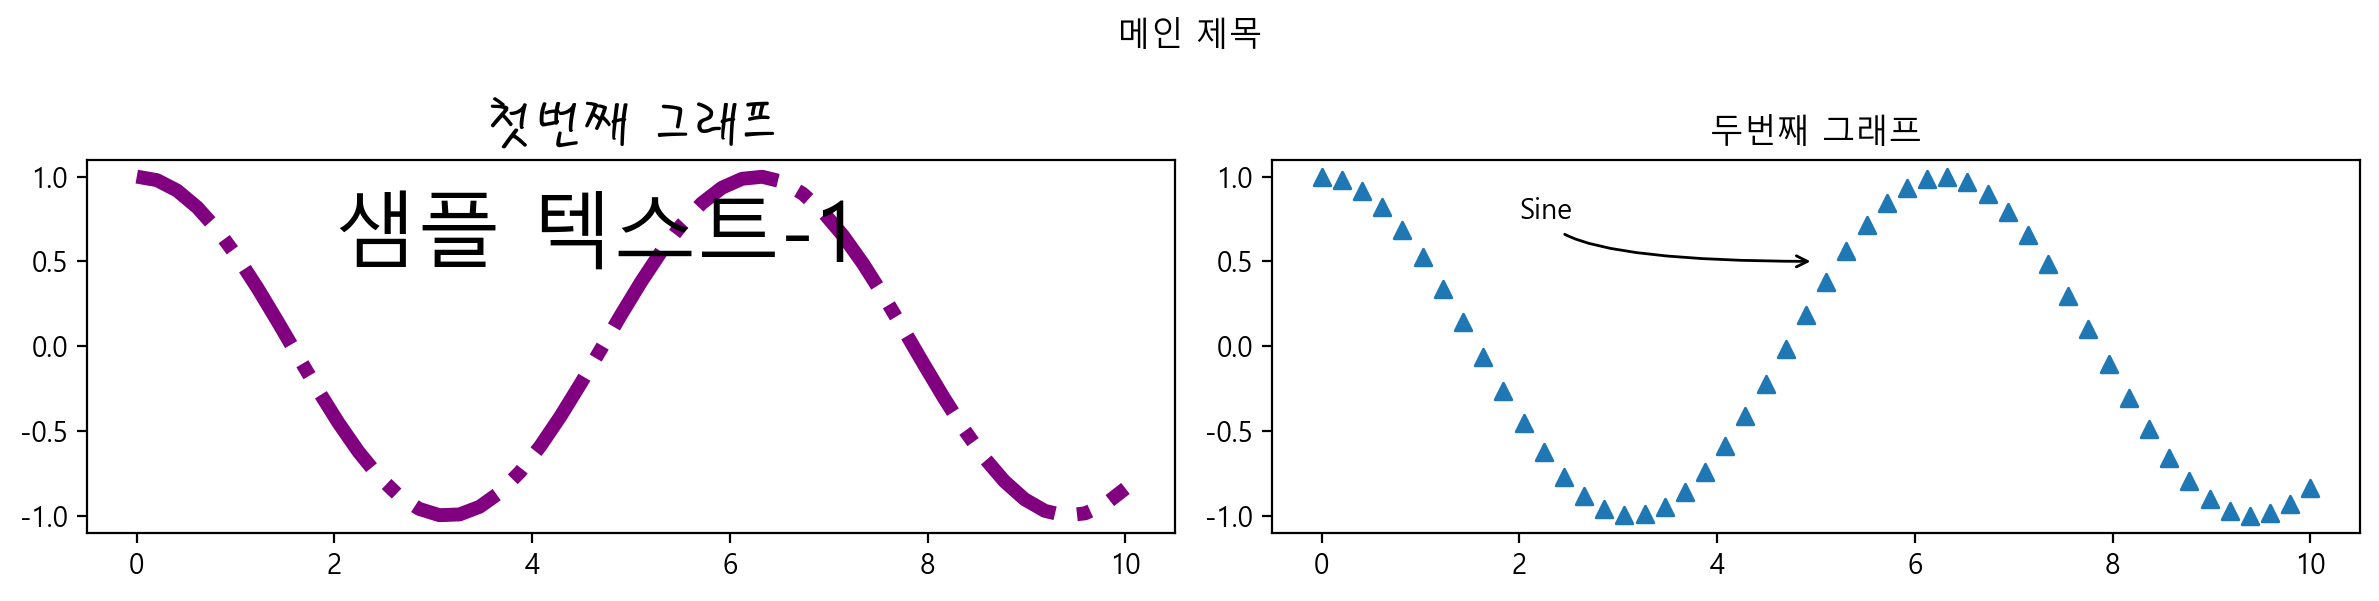

In [28]:
x = np.linspace(0, 10)
y = np.cos(x)
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(x, y, linewidth=5, linestyle='-.', color='purple') # lw=5, ls='-.', c='purple'
# 텍스트 추가
axes[0].text(2, 0.5, # 텍스트가 위치할 곳의 좌표
            '샘플 텍스트-1',
            fontsize=30)
axes[0].set_title('첫번째 그래프', fontproperties=font_prop)
axes[1].scatter(x, y, marker='^')
# annotate 추가
axes[1].annotate('Sine', xytext=(2, 0.75), # 글자가 있을 좌표(좌하)
                xy=(5,0.5),  # 화살표가 가리킬 좌표
                arrowprops=dict(arrowstyle='->',
                               connectionstyle='angle3')) #angle, angle3, arc, ...
axes[1].set_title('두번째 그래프')
plt.suptitle('메인 제목')
plt.tight_layout()
plt.show()

In [29]:
# 한글 폰트 설정 방법3
# pip install koreanize-matplotlib 후
# import koreanize-matplotlib 한줄이면 보통 NanumGothic으로 셋팅

### 3) 수학기호
- https://matplotlib.org/users/mathtext.html (교안30p)

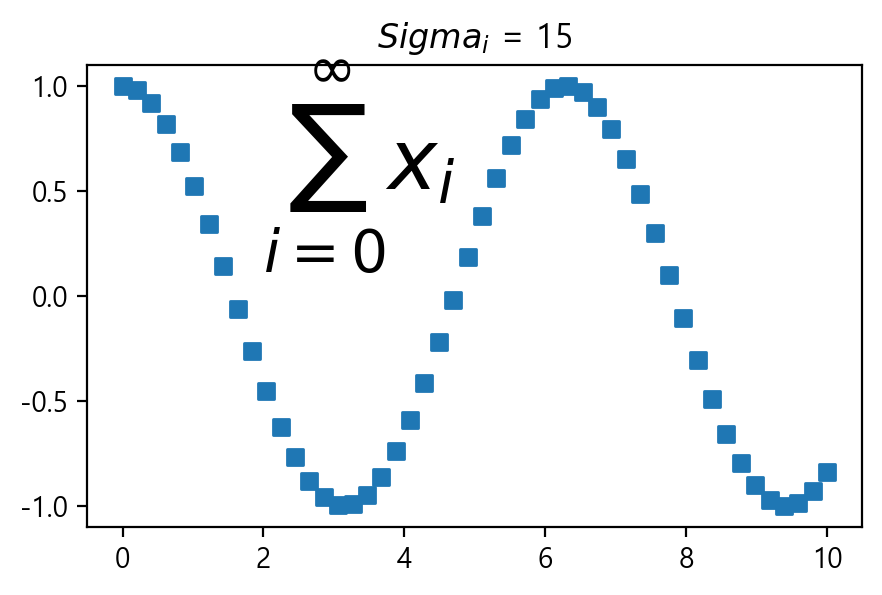

In [30]:
plt.figure(figsize=(5,3))
plt.scatter(x, y, marker='s')
plt.title(r'$Sigma_i$ = 15')
plt.text(2, 0.5, r'$\sum_{i=0}^\infty x_i$', fontsize=30)
plt.show()

### 4) 축과 눈금
- https://matplotlib.org/3.1.0/api/axis_api.html (교안 33p)

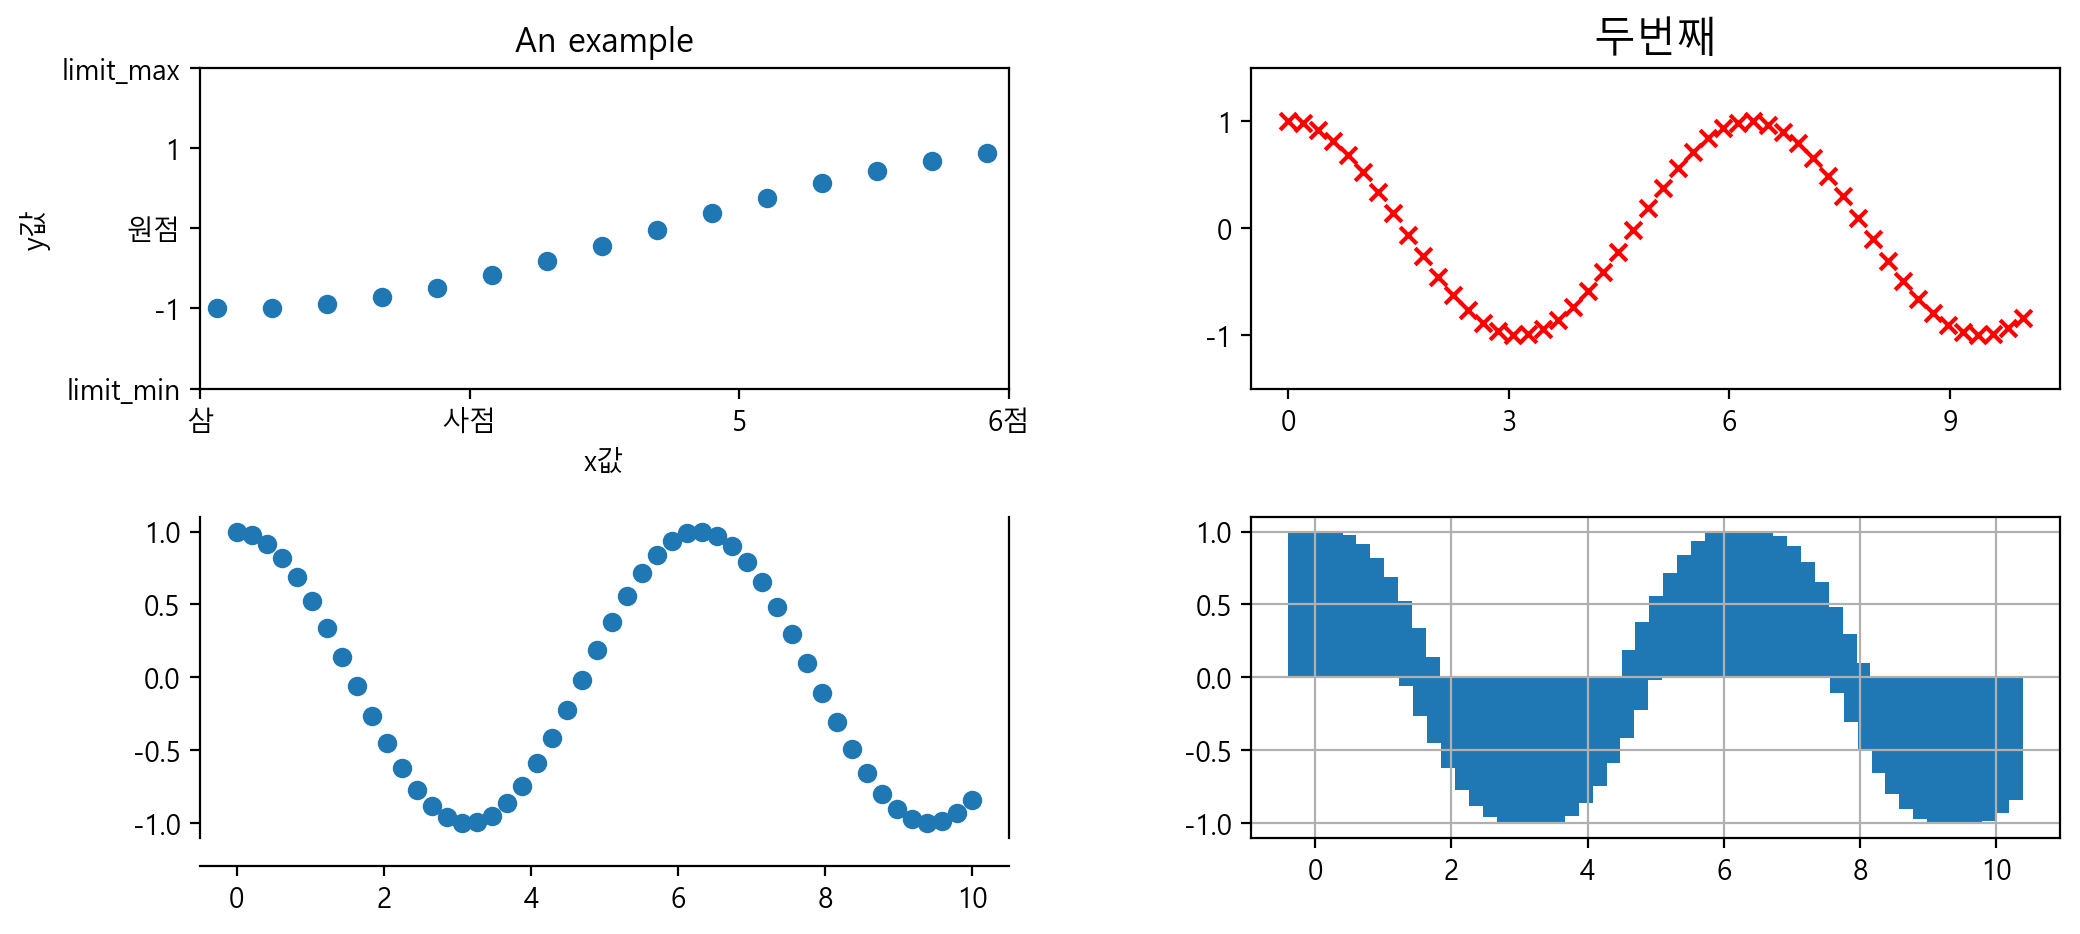

In [57]:
x = np.linspace(0, 10)
y = np.cos(x)

fig, axes = plt.subplots(2, 2, figsize=(12,5))
# subplot끼리 여백 조정
plt.subplots_adjust(hspace=0.4, wspace=0.3) # hspace위아래여백(1은 서브플롯세로높이)
axes[0,0].scatter(x, y)
axes[0,0].set(title='An example', 
             ylabel='y값',
             xlabel='x값',
             ylim=[-2,2], # y축 눈금 범위
             xlim=[3,6],
             yticks=[-2, -1, 0, 1, 2], # y축 눈금
             yticklabels = ['limit_min', -1, '원점', 1, 'limit_max'], # y축 눈금의 라벨
             xticks=[3, 4, 5, 6], 
             xticklabels = ['삼','사점', 5, '6점'])
axes[0,1].scatter(x, y, c='r', marker='x')
axes[0,1].set_title('두번째', fontsize=15)
axes[0,1].set_xticks(range(0, 11, 3))
axes[0,1].set_ylim(-1.5, 1.5)

axes[1,0].scatter(x, y)
axes[1,0].spines['top'].set_visible(False)
axes[1,0].spines['bottom'].set_position( ('outward', 10)) # 10pt만큼 바깥으로 이동

axes[1,1].bar(x, y)
axes[1,1].grid(True)
plt.show()

### 5) ★ 축공유 ★

In [60]:
import numpy as np
x = np.arange(0, 10)
y1 = 0.5*x**2
y2 = -y1
print(x)
print(y1)
print(y2)

[0 1 2 3 4 5 6 7 8 9]
[ 0.   0.5  2.   4.5  8.  12.5 18.  24.5 32.  40.5]
[ -0.   -0.5  -2.   -4.5  -8.  -12.5 -18.  -24.5 -32.  -40.5]


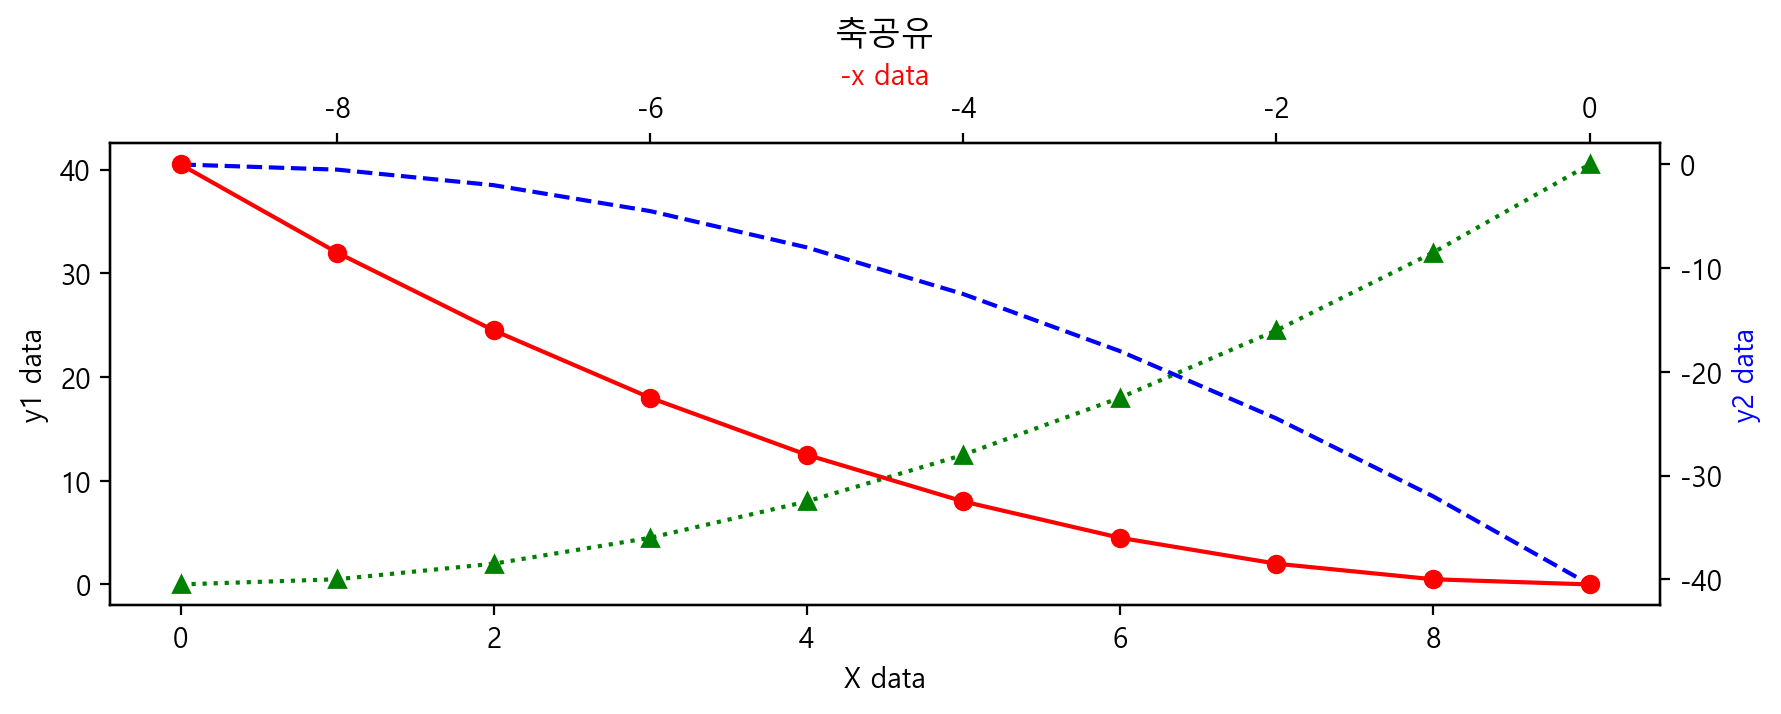

In [69]:
fig, ax1 = plt.subplots(figsize=(10,3))
ax1.plot(x, y1, 'g^:')
ax1.set(title='축공유', xlabel='X data', ylabel='y1 data')

ax2 = ax1.twinx() # ax1과 x축을 공유하는 ax2
ax2.plot(x, y2, 'b--')
ax2.set_ylabel('y2 data', color='b')

ax3 = ax1.twiny() # ax1과 y축을 공유하는 ax3
ax3.plot(-x, y1, 'ro-')
ax3.set_xlabel('-x data', color='r')
plt.show()

### 6) 범례표시
https://stackoverflow.com/questions/30490740/move-legend-outside-figure-in-seaborn-tsplot (교안20p)

### 7) 플롯 스타일 지정
- 플롯 스타일 지정시 플롯의 기존 설정값이 초기화
    * plt.rc('font', family='Malgun Gothic')
    * plt.rc('axes', unicode_minus=False)

In [70]:
plt.style.use('ggplot')
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

In [71]:
plt.style.use('ggplot')
# plt.rcParams['figure.figsize'] = (12,3)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False